In [15]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from sklearn.datasets import make_swiss_roll
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *
from finsler_embedding.utils import *
from torchvision.ops import MLP
from finsler_embedding.omega import *

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d.axes3d import Axes3D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
N = 3000
eps_scale = 1
m=2
def sample_data(N):
    x = torch.rand(N) * 6.4 - 3.2
    y = torch.rand(N) * 4.8 - 2.4
    X = torch.stack([x, y], dim=1)
    return X


In [17]:
class Mountain(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x1 = x[:, 0]
        x2 = x[:, 1]
        # z = (
        #     0.38 * torch.sin(1.15 * x1 + 0.35 * torch.cos(x2))
        #     * torch.cos(1.25 * x2)
        #     + 0.16 * torch.exp(-((x1 + 1.1) ** 2 + (x2 - 0.35) ** 2) / 0.65)
        #     - 0.20 * torch.exp(-((x1 - 0.85) ** 2 + (x2 + 0.55) ** 2) / 0.55)
        #     + 0.07 * torch.cos(0.8 * x1 * x2)
        # )
        z = (0.4 * x1.sin() * x2.cos() 
             + 0.15 * torch.exp(-((x1 + 1.0) ** 2 + (x2 - 0.5) ** 2))
             - 0.15 * torch.exp(-((x1 - 1.0) ** 2 + (x2 + 0.5) ** 2))
        ) 
        return z.unsqueeze(1)

randers_metric = SlopeMetrics(Mountain())
X = sample_data(N)
df =  randers_metric.df_(X.requires_grad_())
assert (df[:,0]**2 + df[:,1]**2).max() < 1/3, "The Slope metric is not well-defined"
Z = Mountain()(X)

X_high = torch.cat([X, Z], dim=1)

In [18]:
cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)


In [19]:
def plot_surface(X,Y,Z,ax: Axes3D,use_wireframe: bool = True):
    ls = LightSource(azdeg=315, altdeg=45)
    rgb = ls.shade(
        Z,
        cmap=cmap,
        vert_exag=0.7,
        blend_mode="soft",
    )

    if use_wireframe:
        ax.plot_wireframe(
            X, Y, Z,
            rstride=5,
            cstride=5,
            linewidth=0.5,
            antialiased=True,
            # alpha=0.96,
            color="black",
        )
    else:
        ax.plot_surface(
            X, Y, Z,
            facecolors=rgb,
            rstride=2,
            cstride=2,
            linewidth=0.,
            antialiased=True,
            shade=False,
            # alpha=0.8,
        )

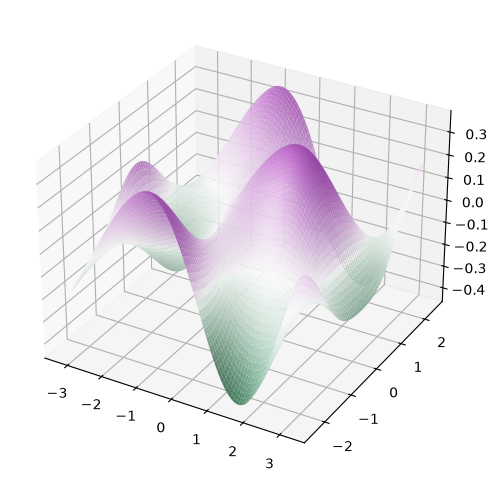

In [20]:
x_plt = torch.linspace(-3.2, 3.2, 180)
y_plt = torch.linspace(-2.4, 2.4, 150)
X_plt, Y_plt = torch.meshgrid(x_plt, y_plt, indexing='ij')

# A smooth "potato-chip" surface with a few broad features
Z_plt = (
    0.38 * torch.sin(1.15 * X_plt + 0.35 * torch.cos(Y_plt))
    * torch.cos(1.25 * Y_plt)
    + 0.16 * torch.exp(-((X_plt + 1.1) ** 2 + (Y_plt - 0.35) ** 2) / 0.65)
    - 0.20 * torch.exp(-((X_plt - 0.85) ** 2 + (Y_plt + 0.55) ** 2) / 0.55)
    + 0.07 * torch.cos(0.8 * X_plt * Y_plt)
)

fig = plt.figure(figsize=(18,6))
ax = fig.add_subplot(1, 1, 1, projection="3d")
plot_surface(X_plt.numpy(),Y_plt.numpy(),Z_plt.numpy(),ax,use_wireframe=False)

In [21]:
edges = get_knn_graph(X_high, n_neighbors=10,device="cpu")
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X_high.requires_grad_(True), edges, randers_metric,use_approx=True)

[2026-09-23 14:29:03] - INFO - Found 34338 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 344/344 [00:00<00:00, 848.60it/s]


In [22]:
isomap = Isomap(n_components=m, n_neighbors=10)
X_low = isomap.fit_transform(X_high.detach())
X_low = torch.from_numpy(X_low).float()
bounds = get_bounds(X_low,margin=0.3)

In [23]:
epsilon = compute_epsilon_empirical(dst_edges, scale=eps_scale)
W, _, _ = gaussian_kernel(edges, dst_edges, epsilon, N, m)
results = randers_approximation(X_low,W, epsilon, m=m)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

In [24]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone().detach()
V_plt = V[idx].clone().detach()
unit_V_plt = unit_V[idx].clone()
z_plt = Z[idx]

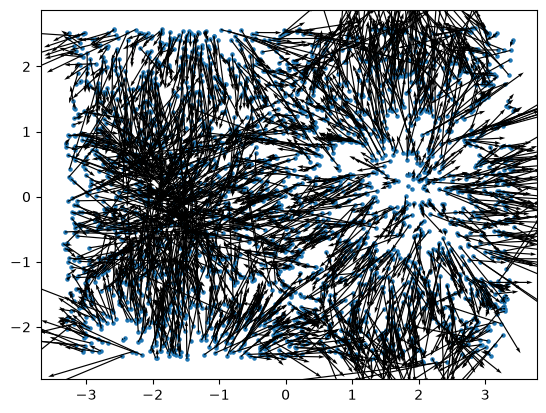

In [25]:
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1],s=5
)
skip=1
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    # unit_V_plt[::skip, 0],
    # unit_V_plt[::skip, 1],
    V_plt[::skip, 0],
    V_plt[::skip, 1],
    color="black",
    scale=1,
    angles="xy",
    scale_units="xy",
    # alpha = results["admissible"][idx][::skip].float().sigmoid()
)

In [26]:
V = V.clone().detach()
model, loss_list = interpolate_V(X_low, V, dim=m)

Loss: 0.1302:   3%|▎         | 14/500 [00:00<00:03, 139.70it/s]

Loss: 0.0775: 100%|██████████| 500/500 [00:01<00:00, 469.93it/s]


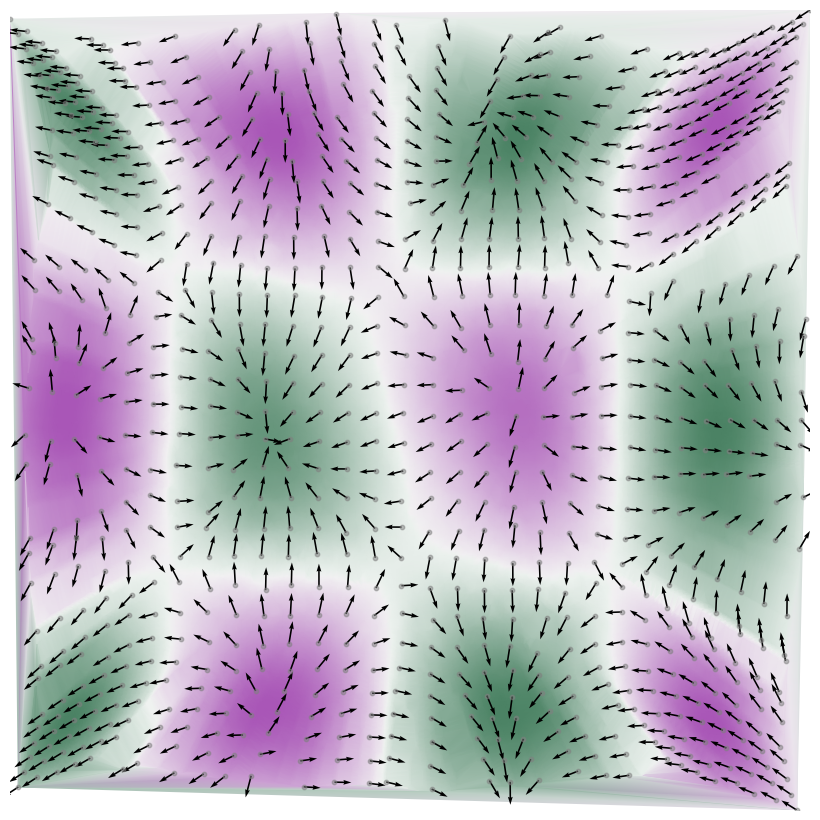

In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


# ============================================================
# Settings
# ============================================================

# Dense grid used to create the smooth background
n_surface = 150

# Coarser grid used for the vector field
n_arrows = 30

# Arrow appearance
arrow_scale = 4
arrow_width = 0.002

# ============================================================
# 1. Dense grid for the scalar field / background
# ============================================================

x = torch.linspace(bounds[0], bounds[1], n_surface)
y = torch.linspace(bounds[2], bounds[3], n_surface)

X_, Y_ = torch.meshgrid(x, y, indexing="ij")

surface_points = torch.stack(
    [X_.flatten(), Y_.flatten()],
    dim=1,
)

# Height map in the original space
with torch.no_grad():
    Z = Mountain()(surface_points)

Z = Z.detach().cpu().numpy().reshape(-1)

# ============================================================
# 2. Map the dense grid through Isomap
# ============================================================

points_grid = torch.cat([surface_points, torch.from_numpy(Z).float().unsqueeze(1)], dim=1)
surface_low = isomap.transform(
    points_grid.detach().cpu().numpy()
)

lx = surface_low[:, 0]
ly = surface_low[:, 1]


# ============================================================
# 3. Triangulate the points in Isomap space
# ============================================================

tri = mtri.Triangulation(lx, ly)


# ============================================================
# 4. Coarse grid for the vector field
# ============================================================

x_arrow = torch.linspace(bounds[0], bounds[1], n_arrows)
y_arrow = torch.linspace(bounds[2], bounds[3], n_arrows)

X_arrow, Y_arrow = torch.meshgrid(
    x_arrow,
    y_arrow,
    indexing="ij",
)

arrow_points = torch.stack(
    [
        X_arrow.flatten(),
        Y_arrow.flatten(),
    ],
    dim=1,
)
z_arrow = Mountain()(arrow_points)
# Map arrow locations through Isomap
arr_high = torch.cat([arrow_points, z_arrow], dim=1)
arrow_low = isomap.transform(
    arr_high.detach().cpu().numpy()
)

arrow_low_torch = torch.from_numpy(
    arrow_low
).float()


# ============================================================
# 5. Evaluate vector field
# ============================================================

with torch.no_grad():
    V = model(arrow_low_torch)

# Normalize vectors
V_unit = V / (
    V.norm(dim=1, keepdim=True)
    + 1e-12
)

V_unit = V_unit.cpu().numpy()


# ============================================================
# 6. Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 8),
)

# ------------------------------------------------------------
# Smooth scalar field
# ------------------------------------------------------------

tpc = ax.tripcolor(
    tri,
    Z,
    cmap=cmap,
    shading="gouraud",
)

# ------------------------------------------------------------
# Vector field
# ------------------------------------------------------------

ax.quiver(
    arrow_low[:, 0],
    arrow_low[:, 1],
    V_unit[:, 0],
    V_unit[:, 1],
    color="black",
    scale=arrow_scale,
    angles="xy",
    scale_units="xy",
    width=arrow_width,
    pivot="tail",
)

ax.scatter(
    arrow_low[:, 0],
    arrow_low[:, 1],
    color="grey",
    s=10,
    alpha=0.5
)

# ============================================================
# 7. Formatting
# ============================================================

# ax.set_aspect("equal")
ax.axis("off")
ax.margins(0)

plt.tight_layout(pad=0)
plt.savefig("matsumoto_vector_field.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

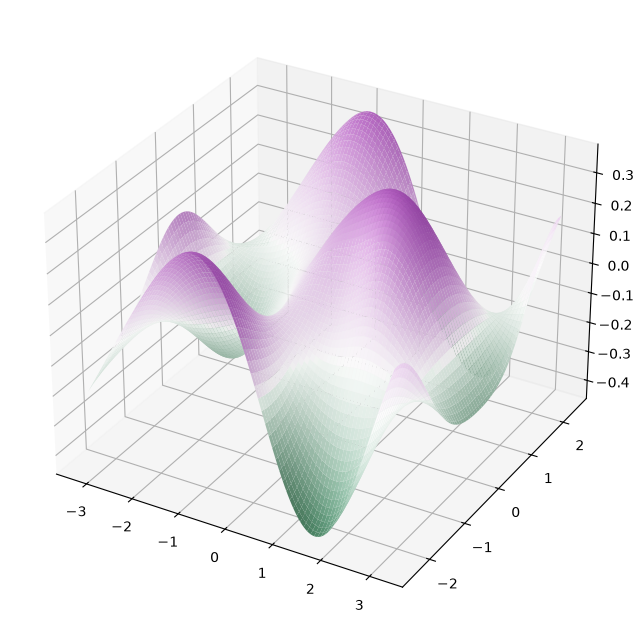

In [28]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d")
plot_surface(X_plt.numpy(),Y_plt.numpy(),Z_plt.numpy(),ax,use_wireframe=False)
fig.savefig("matsumoto_surface.pdf", bbox_inches="tight", pad_inches=0)

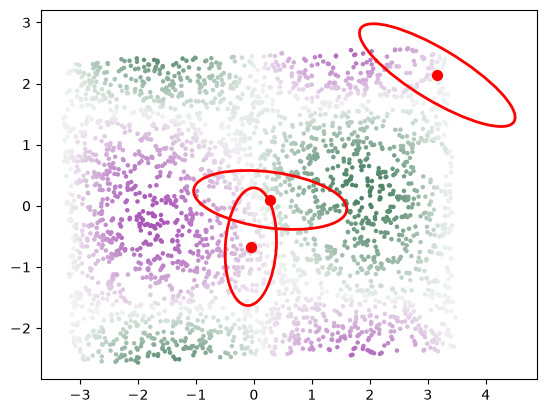

In [16]:
from matplotlib.patches import Ellipse
Gamma = results["Gamma"].shape
density = results["Gamma"].logdet()
plt.scatter(
    X_low_plt[:, 0].detach().numpy(),
    X_low_plt[:, 1].detach().numpy(),
    c=z_plt.detach().numpy(),
    # c=density.detach().numpy(),
    cmap=cmap,
    s=5,
)

# idx = torch.argmin((X_low_plt - torch.tensor([0.0, 0.0])).pow(2).sum(dim=1).sqrt(), dim=0)
idx = torch.randint(0, X_low_plt.shape[0], (3,))
x_0 = X_low_plt[idx]
Gamma_0 = results["Gamma"][idx]
# Build an ellipse from the covariance matrix
eigenvalues, eigenvectors = torch.linalg.eigh(Gamma_0)
angle = 360 * torch.atan2(eigenvectors[:,1, 0], eigenvectors[:,0, 0]) / (2 * np.pi)
sqrt_eigenvals = 2 * torch.sqrt(eigenvalues).detach()
width, height = sqrt_eigenvals[:, 0], sqrt_eigenvals[:, 1]
for i in range(x_0.shape[0]):
    ellipse = Ellipse(
        xy=x_0[i].detach().numpy(),
        width=width[i],
        height=height[i],
        angle=angle[i].detach().numpy(),
        edgecolor="red",
        facecolor="none",
        lw=2,
    )
    ax = plt.gca()
    ax.add_patch(ellipse)
ax.scatter(
    x_0[:,0].detach().numpy(),
    x_0[:,1].detach().numpy(),
    color="red",
    s=50,
    label="Point of Interest",
)

# Draft

In [ ]:
x = torch.linspace(bounds[0], bounds[1], 30)
y = torch.linspace(bounds[2], bounds[3], 30)
X, Y = torch.meshgrid(x, y, indexing="ij")
X = torch.stack([X.flatten(), Y.flatten()], dim=1)
Z = Mountain()(X)

plt.scatter(X[:, 0], X[:, 1], c=Z,cmap=cmap,s=5)
plt.imshow(
    Z.reshape((30, 30)).numpy().T,
    extent=(bounds[0], bounds[1], bounds[2], bounds[3]),
    origin="lower",
    cmap=cmap,
    interpolation="bilinear",
)

In [ ]:
theta = torch.linspace(0, 2 * np.pi, 100)
v = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)
randers_metric = SlopeMetrics(Mountain())

X_0 = torch.tensor([[-3.0, 2.0]])
X_0_ = X_0.repeat(100, 1).clone().detach().requires_grad_(True)
v_x = randers_metric(X_0_, v)
v = v / v_x[:,None]
c = (X_0 + v.mean(dim=0)).detach()

v_ball = (X_0_ + v).detach()

plt.imshow(
    Z.reshape((30, 30)).numpy().T,
    extent=(bounds[0], bounds[1], bounds[2], bounds[3]),
    origin="lower",
    cmap=cmap,
    interpolation="bilinear",
)
plt.scatter(X[:, 0], X[:, 1], c=Z,cmap=cmap,s=5)
plt.scatter(X_0[:, 0], X_0[:, 1], c="red", s=50)
plt.scatter(c[:, 0], c[:, 1], c="blue", s=50)
plt.plot(v_ball[:, 0], v_ball[:, 1], c="black")

In [ ]:
c

In [ ]:
V = results["V"].clone().detach()
Gamma = results["Gamma"].clone().detach()
H_tilde = results["H_tilde"].clone().detach()
kappa = results["kappa"]
results.keys()

In [ ]:
import math


class F_approx_true(torch.nn.Module):
    def __init__(self, V, H_tilde, kappa):
        super().__init__()
        self.V = V
        self.H_tilde = H_tilde
        self.kappa = kappa

    def forward(self, pts_idx, v):
        V_x = self.V[pts_idx]
        H_x = self.H_tilde[pts_idx]
        c_x = math.sqrt(self.kappa) * V_x
        lambda_x = 1 - torch.einsum("bij,bi,bj->b", H_x, V_x, V_x)
        v_norm_sq = torch.einsum("bij,bi,bj->b", H_x, v, v)
        v_dot_c = torch.einsum("bij,bi,bj->b", H_x, v, c_x)
        inside_sqrt = lambda_x * v_norm_sq + v_dot_c ** 2
        F_x_v = 1/lambda_x * ( torch.sqrt(inside_sqrt) - v_dot_c )

        # Get only the well defined points
        keep = inside_sqrt > 0
        F_x_v = F_x_v[keep]
        return F_x_v,keep

import torch
import torch.nn as nn
import torch.nn.functional as F


class FinslerMetric(nn.Module):
    def __init__(self, x_dim, v_dim, hidden_dim=128, n_layers=3):
        super().__init__()

        layers = []
        in_dim = x_dim + v_dim

        for i in range(n_layers):
            layers.append(nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim))
            layers.append(nn.SiLU())

        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, v):
        """
        x: (..., x_dim)
        v: (..., v_dim)

        returns:
            F(x, v): (...,)
        """
        norm = torch.linalg.vector_norm(v, dim=-1, keepdim=True)

        # Direction of v. eps avoids division by zero numerically.
        u = v / norm.clamp_min(1e-12)

        # Positive scalar function on (x, sphere).
        raw = self.net(torch.cat([x, u], dim=-1))
        phi = F.softplus(raw) + 1e-6

        return norm.squeeze(-1) * phi.squeeze(-1)

F_approx = F_approx_true(V, H_tilde, kappa)
F_model = FinslerMetric(x_dim=2, v_dim=2, hidden_dim=128, n_layers=3)
# F_approx(idx,torch.randn(3,2))
# F_model(X_low[idx],torch.randn(X_low[idx].shape[0],2))
optimizer = torch.optim.Adam(F_model.parameters(), lr=1e-3)

loss_list = []
pbar = tqdm(range(5000))
for epoch in pbar:
    optimizer.zero_grad()
    # Sample a batch of points and vectors
    idx_batch = torch.randint(0, X_low.shape[0], (64,))
    v_batch = torch.randn(64, 2)
    F_true, keep = F_approx(idx_batch, v_batch)
    F_pred = F_model(X_low[idx_batch], v_batch)[keep]
    loss = torch.mean((F_true - F_pred) ** 2)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())
    pbar.set_description(f"Loss: {loss.item():.4e}")

In [ ]:
plt.plot(loss_list)
plt.yscale("log")

In [ ]:
K = 100
# Pick a pont
idx = torch.randint(0, X_low.shape[0], (1,))
X_ball = X_low[idx].clone().detach()
X_ball = X_ball.repeat(K, 1)

# Sample v in a ball around the origin
theta = torch.linspace(-math.pi, math.pi, K)
r = torch.rand(K) * 0.5
v_ball = torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)
F_v = F_model(X_ball, v_ball).detach()

v_ball = v_ball / (F_v.unsqueeze(1) + 1e-12)

ball_pts = X_ball + v_ball

In [ ]:
# plt.scatter(X_low[:, 0], X_low[:, 1], cmap=cmap, s=10)
plt.imshow(
    grid_img,
    extent=(bounds[0], bounds[1], bounds[2], bounds[3]),
    origin="lower",
    cmap="coolwarm",
    alpha=0.5,
    interpolation="bilinear",
)
plt.scatter(X_ball[:, 0], X_ball[:, 1], color="red", s=50)
plt.plot(ball_pts[:, 0], ball_pts[:, 1], color="blue", alpha=0.5)